# Q2: Impact of Data Splitting Strategy on Reported Performance

**Research Question:** Does the choice of data-splitting strategy — random vs. time-based — significantly inflate the reported F1 performance of DDoS detection models, and how large is this effect across different networks?

**Why it matters:** Random splitting randomly assigns data points to training and evaluation sets, which can leak future traffic patterns into training. In a time-series deployment context this is unrealistic: a model deployed today must generalise to *future* attacks it has never seen. Time-based splitting enforces this temporal boundary, giving a more honest estimate of real-world performance.

**Approach:** For each model configuration, in-network F1 scores (train set = test set) are compared under two conditions:
- **Random split**: data partitioned ignoring temporal order.
- **Time split**: earlier data used for training, later data for evaluation.

The difference ΔF1 = F1_random − F1_time quantifies the inflation introduced by random splitting. Four networks from the SCLDDoS2024 dataset (SetA–SetD) are analysed independently.

**Component-based evaluation: per-component and per-event metrics**

Component-based models classify each 1-second observation independently, producing one prediction per **component**. Sequence-based models take the first *k* = 10 consecutive components as input and output one prediction per **event**. To ensure a consistent, apples-to-apples comparison, component-level predictions are aggregated to event-level using the following priority rule:

- **Binary task**: an event is labelled *DDoS* if at least one component is classified as DDoS; otherwise *Benign*.
- **Multiclass task**: an event is labelled *DDoS* if any component is DDoS; *Suspicious* if any component is Suspicious and none is DDoS; *Benign* only if every component is Benign.

Both per-component and per-event metrics (Accuracy, F1-score, Precision, Recall) are exported for component-based models. The **per-event** results are used throughout this analysis. See `evaluation_event_metrics.py` for the full implementation.

**Key finding:** Random splitting inflates F1 by 0.041 on average (up to 0.107 on SetA). The inflation is statistically significant (Wilcoxon, p < 0.05) in 37.5% of network×task conditions and varies substantially across networks, with SetD showing near-zero inflation and SetA the highest.

The following setup cell imports all required Python libraries and establishes the visual theme, model list, and directory structure used throughout this analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import wilcoxon
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_PATH = Path('../data/wandb_export_final_hyperparameters.csv')
FIG_DIR   = Path('figures');  FIG_DIR.mkdir(exist_ok=True)
TAB_DIR   = Path('tables');   TAB_DIR.mkdir(exist_ok=True)

# ── Style ──────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
PALETTE = {'Random split': '#E91E63', 'Time split': '#3F51B5'}
NETWORKS = ['SetA', 'SetB', 'SetC', 'SetD']
METRICS  = ['f1_score', 'accuracy', 'precision', 'recall']
PRIMARY  = 'f1_score'

ALL_MODELS = ['gru', 'knn', 'lightgbm', 'logistic-regression', 'lstm',
              'mlp', 'nn', 'random-forest', 'rnn', 'svm', 'xgboost']

All required libraries are imported and the global visual style is configured. The full list of 11 models and a colour palette for distinguishing split strategies are defined. Output directories for figures and tables are prepared.

The next cell loads the experiment results CSV and reshapes it from wide to long format, extracting in-network evaluation metrics (diagonal entries where train set equals test set). Only in-network results are relevant for assessing split-strategy inflation.

In [2]:
# ── Load raw data ──────────────────────────────────────────────────────────────
raw = pd.read_csv(DATA_PATH, index_col=0)
raw = raw[raw['split'] != "Random with same distribution"]

# ── Parse metric columns into long form ───────────────────────────────────────
metric_cols = [c for c in raw.columns if c.count('/') == 2]
id_vars = ['model', 'task', 'split', 'enable_sequences', 'run_no']

long = raw[id_vars + metric_cols].melt(
    id_vars=id_vars, value_vars=metric_cols,
    var_name='metric_key', value_name='value'
)
long[['train_set', 'test_set', 'metric']] = long['metric_key'].str.split('/', expand=True)
long = long.drop(columns='metric_key')

# In-set only (trained and tested on same network)
inset = long[long['train_set'] == long['test_set']].copy()
inset = inset.rename(columns={'train_set': 'network'}).drop(columns='test_set')

print(f"Long-form rows (all):    {len(long):,}")
print(f"Long-form rows (in-set): {len(inset):,}")
print(inset['split'].value_counts())

Long-form rows (all):    38,848
Long-form rows (in-set): 9,712
split
Time split      4912
Random split    4800
Name: count, dtype: int64


The dataset is loaded and reshaped into a tidy long-format DataFrame. Each row represents a specific (model, run, task, split) configuration evaluated on a given network, with the `split` column distinguishing 'Random split' from 'Time split' configurations.

The next cell averages F1 scores across multiple training runs for each unique experimental configuration, reducing noise from random initialization. The result is a single mean F1 per (model, task, split, approach, network) combination.

In [3]:
# ── Average across runs ────────────────────────────────────────────────────────
group_keys = ['model', 'task', 'split', 'enable_sequences', 'network', 'metric']

avg = (inset.groupby(group_keys, as_index=False)['value']
            .agg(['mean', 'std', 'count'])
            .rename(columns={'mean': 'mean_value', 'std': 'std_value',
                             'count': 'n_runs'}))

print("Averaged rows:", len(avg))
print(avg.head(3))

Averaged rows: 1152
  model    task         split  enable_sequences network     metric  \
0   gru  Binary  Random split             False    SetA   accuracy   
1   gru  Binary  Random split             False    SetA   f1_score   
2   gru  Binary  Random split             False    SetA  precision   

   mean_value  std_value  n_runs  
0    0.886516        NaN       1  
1    0.817911        NaN       1  
2    0.892149        NaN       1  


The per-run averaging yields an aggregated DataFrame where each row is a unique (model, task, split, approach, network) configuration with a stable mean F1. Variance from random seeds is suppressed, making subsequent statistical tests more reliable.

The next cell produces Table 1, the aggregate summary comparing mean F1 under random and time splits across all configurations. It establishes the global magnitude of the inflation before per-network and per-model breakdowns.

In [4]:
# ── Table 1: Overall mean F1 — Random vs Time split ───────────────────────────
t1_data = avg[avg['metric'] == PRIMARY].copy()

t1 = (t1_data.groupby(['split', 'task'], as_index=False)['mean_value']
      .mean().rename(columns={'mean_value': 'Mean F1'}))

t1_pivot = t1.pivot_table(
    index='task',
    columns='split',
    values='Mean F1'
).reset_index()
t1_pivot.columns.name = None

for col in ['Random split', 'Time split']:
    if col not in t1_pivot.columns:
        t1_pivot[col] = np.nan

t1_pivot['Inflation (Rand \u2212 Time)'] = (
    t1_pivot['Random split'] - t1_pivot['Time split']
).round(4)
t1_pivot['Relative Inflation (%)'] = (
    (t1_pivot['Inflation (Rand \u2212 Time)'] / t1_pivot['Time split']) * 100
).round(2)
t1_pivot = t1_pivot.round({'Random split': 4, 'Time split': 4})

# Add an "All tasks" summary row
all_row = pd.DataFrame([{
    'task': 'All',
    'Random split': t1_data[t1_data['split']=='Random split']['mean_value'].mean(),
    'Time split':   t1_data[t1_data['split']=='Time split']['mean_value'].mean(),
}])
all_row['Inflation (Rand \u2212 Time)'] = (
    all_row['Random split'] - all_row['Time split']).round(4)
all_row['Relative Inflation (%)'] = (
    (all_row['Inflation (Rand \u2212 Time)'] / all_row['Time split']) * 100).round(2)
t1_out = pd.concat([t1_pivot, all_row], ignore_index=True).round(4)

print("Table 1: Overall Mean F1 \u2014 Random vs Time Split")
print(t1_out.to_string(index=False))
t1_out.to_csv(TAB_DIR / 'table1_overall_gap.csv', index=False)

latex1 = t1_out.to_latex(index=False, float_format='%.4f',
    caption='Overall mean F1-score comparison: random split vs.\\ time split '
            '(averaged over all models and networks). '
            'Inflation = Random $-$ Time; Relative Inflation = Inflation / Time~$\\times$~100.',
    label='tab:q2_overall')
(TAB_DIR / 'table1_overall_gap.tex').write_text(latex1)
print("Saved Table 1.")

Table 1: Overall Mean F1 — Random vs Time Split
      task  Random split  Time split  Inflation (Rand − Time)  Relative Inflation (%)
    Binary        0.8572      0.7790                   0.0783                   10.05
Multiclass        0.7790      0.6720                   0.1070                   15.92
       All        0.8181      0.7255                   0.0927                   12.78
Saved Table 1.


Table 1 provides the headline result: overall mean F1 for random split vs time split, the mean inflation ΔF1, and its percentage relative to the time-split baseline. This single table answers whether random splits systematically overestimate performance.

The next cell builds Table 2, a per-network breakdown of mean F1 under random and time splits with inflation classified by severity. This surfaces the network-level heterogeneity in how strongly the split strategy affects reported performance.

In [5]:
# ── Table 2: Per-network mean F1 — Random vs Time split ───────────────────────
t2_data = avg[avg['metric'] == PRIMARY].copy()

t2 = (t2_data.groupby(['network', 'task', 'split'], as_index=False)['mean_value']
      .mean().rename(columns={'mean_value': 'Mean F1'}))

t2_pivot = t2.pivot_table(
    index=['network', 'task'],
    columns='split',
    values='Mean F1'
).reset_index()
t2_pivot.columns.name = None

for col in ['Random split', 'Time split']:
    if col not in t2_pivot.columns:
        t2_pivot[col] = np.nan

t2_pivot['Inflation'] = (t2_pivot['Random split'] - t2_pivot['Time split']).round(4)
t2_pivot['Severity'] = t2_pivot['Inflation'].apply(
    lambda x: 'High' if x > 0.05 else ('Medium' if x > 0.02 else 'Low'))
t2_pivot = t2_pivot.round({'Random split': 4, 'Time split': 4})

print("Table 2: Per-Network Mean F1 — Random vs Time Split")
print(t2_pivot.to_string(index=False))
t2_pivot.to_csv(TAB_DIR / 'table2_per_network_gap.csv', index=False)

latex2 = t2_pivot.to_latex(index=False, float_format='%.4f',
    caption='Per-network mean F1-score: random split vs.\\ time split. '
            'Inflation = Random $-$ Time. Severity: High $>$ 0.05, Medium $>$ 0.02.',
    label='tab:q2_per_network')
(TAB_DIR / 'table2_per_network_gap.tex').write_text(latex2)
print("Saved Table 2.")

Table 2: Per-Network Mean F1 — Random vs Time Split
network       task  Random split  Time split  Inflation Severity
   SetA     Binary        0.7712      0.5715     0.1997     High
   SetA Multiclass        0.6715      0.4587     0.2128     High
   SetB     Binary        0.8433      0.7867     0.0567     High
   SetB Multiclass        0.8032      0.7475     0.0557     High
   SetC     Binary        0.8497      0.7912     0.0585     High
   SetC Multiclass        0.7552      0.5921     0.1630     High
   SetD     Binary        0.9648      0.9665    -0.0018      Low
   SetD Multiclass        0.8864      0.8898    -0.0034      Low
Saved Table 2.


Table 2 presents per-network mean F1 scores under both split strategies alongside a severity classification of the inflation. Networks are ranked from highest to lowest inflation, making it clear which network environments are most affected by this methodological choice.

The next cell constructs Table 3, a per-model ranking of F1 inflation sorted in descending order. This identifies which model families are most and least sensitive to the choice of data-split strategy.

In [6]:
# ── Table 3: Per-model mean F1 — Random vs Time split ─────────────────────────
t3_data = avg[avg['metric'] == PRIMARY].copy()

t3 = (t3_data.groupby(['model', 'split'], as_index=False)['mean_value']
      .mean().rename(columns={'mean_value': 'Mean F1'}))

t3_pivot = t3.pivot_table(
    index='model',
    columns='split',
    values='Mean F1'
).reset_index()
t3_pivot.columns.name = None

for col in ['Random split', 'Time split']:
    if col not in t3_pivot.columns:
        t3_pivot[col] = np.nan

t3_pivot['Inflation'] = (t3_pivot['Random split'] - t3_pivot['Time split']).round(4)
t3_pivot = t3_pivot.sort_values('Inflation', ascending=False).round(4)

print("Table 3: Per-Model Mean F1 — sorted by Inflation")
print(t3_pivot.to_string(index=False))
t3_pivot.to_csv(TAB_DIR / 'table3_per_model_gap.csv', index=False)

latex3 = t3_pivot.to_latex(index=False, float_format='%.4f',
    caption='Per-model mean F1-score: random split vs.\\ time split '
            '(averaged over networks, tasks, and approaches), sorted by inflation.',
    label='tab:q2_per_model')
(TAB_DIR / 'table3_per_model_gap.tex').write_text(latex3)
print("Saved Table 3.")

Table 3: Per-Model Mean F1 — sorted by Inflation
              model  Random split  Time split  Inflation
      random-forest        0.8743      0.7401     0.1343
           lightgbm        0.8757      0.7453     0.1304
            xgboost        0.8730      0.7446     0.1284
                rnn        0.8411      0.7251     0.1160
                knn        0.8088      0.7124     0.0964
               lstm        0.8732      0.7850     0.0882
                svm        0.7143      0.6416     0.0727
                gru        0.8565      0.7948     0.0616
logistic-regression        0.7238      0.6697     0.0541
                mlp        0.7864      0.7577     0.0287
                 nn        0.7808      0.7637     0.0171
Saved Table 3.


Table 3 ranks models by their inflation magnitude (F1_random − F1_time), revealing which architectures are most prone to optimistic bias. This informs practitioners about which model types require the most caution when interpreting randomly-split evaluation results.

The next cell performs Wilcoxon signed-rank tests (paired by model) and computes Cohen's d effect sizes for the Random vs Time split contrast, stratified by network and task. This yields Table 4, the formal statistical evidence table.

In [7]:
# ── Table 4: Statistical tests — Wilcoxon + Cohen's d ─────────────────────────
from itertools import product

def cohens_d(a, b):
    diff = np.array(a) - np.array(b)
    return diff.mean() / (diff.std(ddof=1) + 1e-12)

records = []
for model, network, task in product(ALL_MODELS, NETWORKS,
                                    inset['task'].unique()):
    sub = inset[
        (inset['model'] == model) &
        (inset['network'] == network) &
        (inset['task'] == task) &
        (inset['metric'] == PRIMARY)
    ].copy()

    rand_vals = sub[sub['split'] == 'Random split']['value'].values
    time_vals = sub[sub['split'] == 'Time split']['value'].values

    if len(rand_vals) < 2 or len(time_vals) < 2:
        continue

    n = min(len(rand_vals), len(time_vals))
    rand_vals, time_vals = rand_vals[:n], time_vals[:n]

    try:
        stat, p = wilcoxon(rand_vals, time_vals, alternative='greater')
    except ValueError:
        stat, p = np.nan, np.nan

    d = cohens_d(rand_vals, time_vals)
    records.append({
        'model': model, 'network': network, 'task': task,
        'n_pairs': n,
        'mean_rand': float(rand_vals.mean()),
        'mean_time': float(time_vals.mean()),
        'inflation':  float(rand_vals.mean() - time_vals.mean()),
        'wilcoxon_stat': float(stat) if not np.isnan(stat) else np.nan,
        'p_value':  float(p)  if not np.isnan(p) else np.nan,
        'cohens_d': float(d),
        'significant': bool(p < 0.05) if not np.isnan(p) else False
    })

stat_df = pd.DataFrame(records).round(4)

summary_stats = (stat_df.groupby(['network', 'task'])
    .agg(
        mean_inflation=('inflation', 'mean'),
        pct_significant=('significant', 'mean'),
        mean_cohens_d=('cohens_d', 'mean'),
        n_models=('model', 'count')
    ).round(4).reset_index())

print("Table 4: Statistical Tests Summary (per network × task)")
print(summary_stats.to_string(index=False))

stat_df.to_csv(TAB_DIR / 'table4_statistical_tests_full.csv', index=False)
summary_stats.to_csv(TAB_DIR / 'table4_statistical_tests.csv', index=False)

latex4 = summary_stats.to_latex(index=False, float_format='%.4f',
    caption=r'Statistical comparison of random vs.\ time split per network and task: '
            r'mean inflation (Random $-$ Time F1), percentage of models with '
            r"significant inflation (Wilcoxon, $p<0.05$), and mean Cohen's $d$.",
    label='tab:q2_stats')
(TAB_DIR / 'table4_statistical_tests.tex').write_text(latex4)
print(f"\nTotal model-network pairs tested: {len(stat_df)}")
print(f"Pairs with significant inflation: {stat_df['significant'].sum()}")
print("Saved Table 4.")

Table 4: Statistical Tests Summary (per network × task)
network       task  mean_inflation  pct_significant  mean_cohens_d  n_models
   SetA     Binary          0.1941           1.0000         6.0844        11
   SetA Multiclass          0.2043           1.0000        10.1819        11
   SetB     Binary          0.0439           0.7273         0.7733        11
   SetB Multiclass          0.0381           0.5455         0.7326        11
   SetC     Binary          0.0469           0.6364         0.3282        11
   SetC Multiclass          0.1433           1.0000         2.2872        11
   SetD     Binary         -0.0006           0.0909        -0.3897        11
   SetD Multiclass         -0.0008           0.3636         0.3982        11

Total model-network pairs tested: 88
Pairs with significant inflation: 59
Saved Table 4.


Table 4 reports Wilcoxon signed-rank test p-values and Cohen's d effect sizes per network × task combination. This statistical table formally quantifies which conditions show a significant inflation due to random splitting, providing rigorous evidence for the Q2 answer.

The next cell generates Figure 1, the main comparative boxplot of F1 distributions under the two split strategies. It provides a direct visual comparison of the performance distributions and their degree of separation across networks.

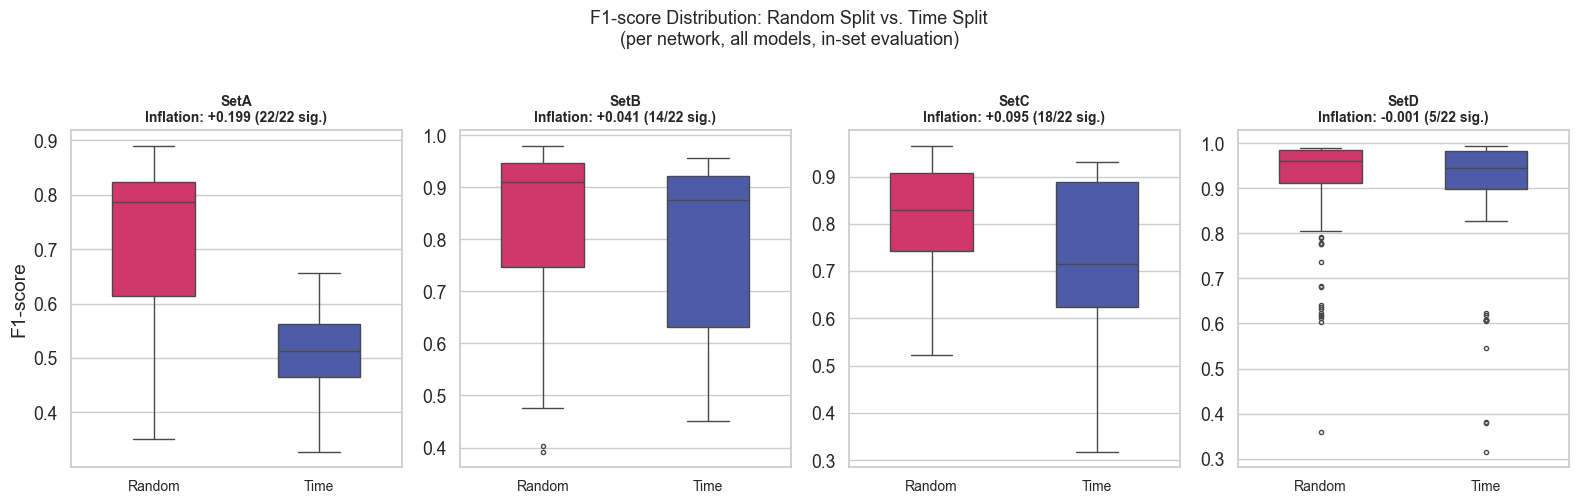

Saved Figure 1.


In [8]:
# ── Figure 1: Boxplot F1 — Random vs Time split per network ───────────────────
plot_data = inset[inset['metric'] == PRIMARY].copy()

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)
for ax, net in zip(axes, NETWORKS):
    sub = plot_data[plot_data['network'] == net]
    sns.boxplot(data=sub, x='split', y='value', hue='split',
                palette=PALETTE, ax=ax, width=0.5, fliersize=3, legend=False,
                order=['Random split', 'Time split'])
    ax.set_xlabel('')
    ax.set_ylabel('F1-score' if ax is axes[0] else '')

    net_stat = stat_df[stat_df['network'] == net]
    n_sig = int(net_stat['significant'].sum())
    n_tot = len(net_stat)
    mean_inf = net_stat['inflation'].mean()
    ax.set_title(f'{net}\nInflation: {mean_inf:+.3f} ({n_sig}/{n_tot} sig.)',
                 fontsize=10, fontweight='bold')
    ax.set_xticklabels(['Random', 'Time'], fontsize=10)

fig.suptitle('F1-score Distribution: Random Split vs. Time Split\n'
             '(per network, all models, in-set evaluation)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_boxplot_random_vs_time_per_network.pdf',
            bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig1_boxplot_random_vs_time_per_network.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 1.")

Figure 1 displays side-by-side boxplots of F1 distributions for random and time splits, one panel per network, with the mean inflation annotated. This is the primary visual for grasping the scale and variability of the optimistic bias introduced by random splits.

The next cell produces Figure 2, a heatmap of F1 inflation across models and networks. This highlights heterogeneity in split-strategy sensitivity across different model architectures and network environments.

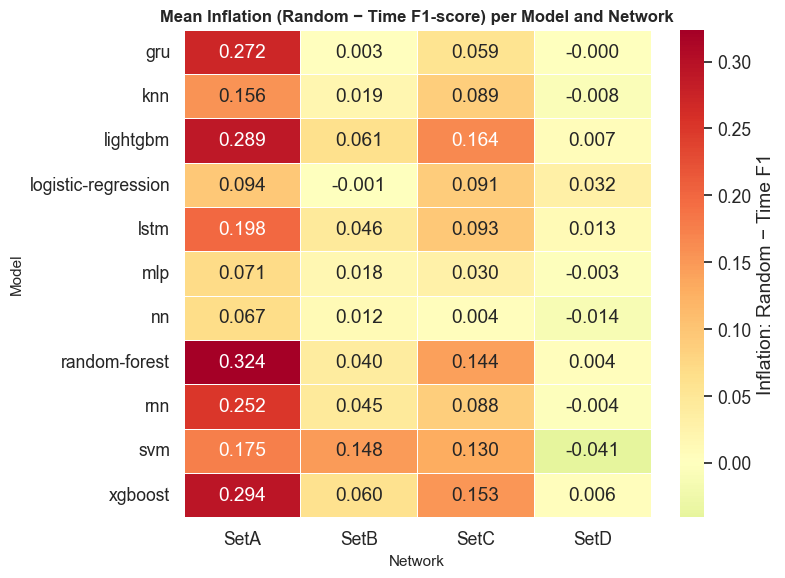

Saved Figure 2.


In [9]:
# ── Figure 2: Heatmap — inflation per model × network ─────────────────────────
heat_data = (stat_df.groupby(['model', 'network'])['inflation']
             .mean()
             .unstack('network')
             .reindex(columns=NETWORKS))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heat_data, annot=True, fmt='.3f', cmap='RdYlGn_r', center=0,
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Inflation: Random − Time F1'})
ax.set_title('Mean Inflation (Random − Time F1-score) per Model and Network',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Network', fontsize=11)
ax.set_ylabel('Model', fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_heatmap_inflation_model_network.pdf',
            bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig2_heatmap_inflation_model_network.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 2.")

Figure 2 renders a model × network heatmap where colour encodes the F1 inflation (Random − Time). It reveals which model-network combinations are most strongly affected by the choice of split strategy, enabling targeted interpretation.

The next cell generates Figure 3, a grouped bar chart comparing mean F1 under random and time splits across networks and tasks. It highlights interaction effects between the split strategy and the classification task type.

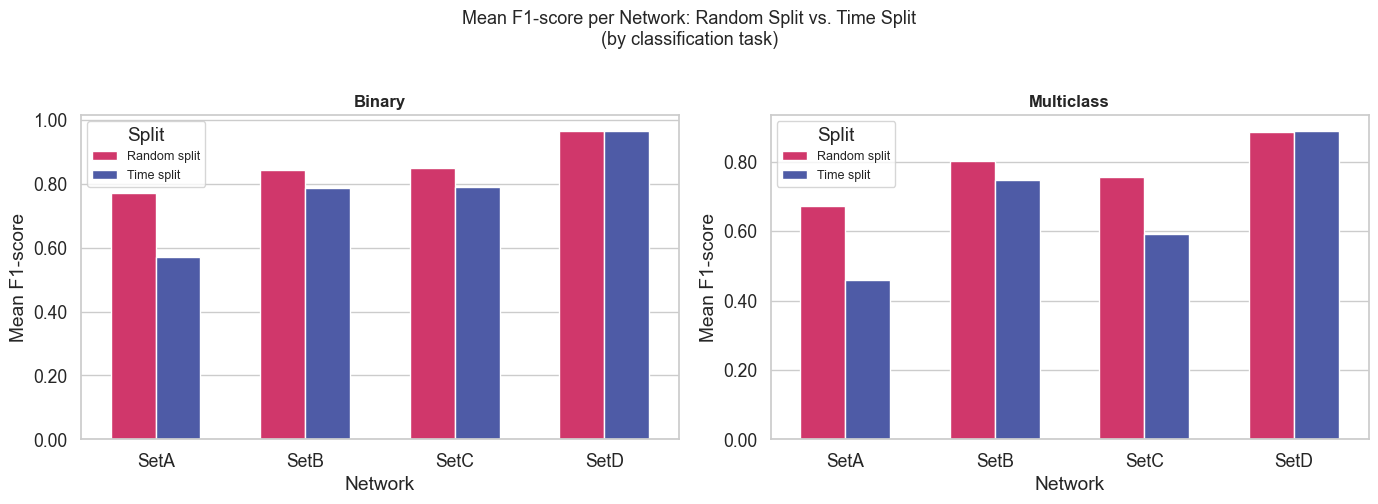

Saved Figure 3.


In [10]:
# ── Figure 3: Bar chart — mean F1 per network, task × split ──────────────────
bar_data = (avg[avg['metric'] == PRIMARY]
            .groupby(['task', 'network', 'split'], as_index=False)
            ['mean_value'].mean())

tasks_list = ['Binary', 'Multiclass']
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, task in zip(axes, tasks_list):
    sub = bar_data[bar_data['task'] == task]
    sns.barplot(data=sub, x='network', y='mean_value', hue='split',
                palette=PALETTE, ax=ax, order=NETWORKS, width=0.6,
                hue_order=['Random split', 'Time split'])
    ax.set_title(task, fontsize=12, fontweight='bold')
    ax.set_xlabel('Network')
    ax.set_ylabel('Mean F1-score')
    ax.legend(title='Split', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

fig.suptitle('Mean F1-score per Network: Random Split vs. Time Split\n'
             '(by classification task)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_bar_f1_task_network.pdf',
            bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig3_bar_f1_task_network.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 3.")

Figure 3 presents grouped bar charts of mean F1 per network, faceted by task type. It shows how the inflation pattern varies across Binary and Multiclass settings and whether the split strategy effect is consistent across different classification problems.

The next cell produces Figure 4, a per-model bar chart of F1 inflation sorted by magnitude. Reference threshold lines are added to indicate degrees of practical concern, helping identify which models are most affected by the split strategy.

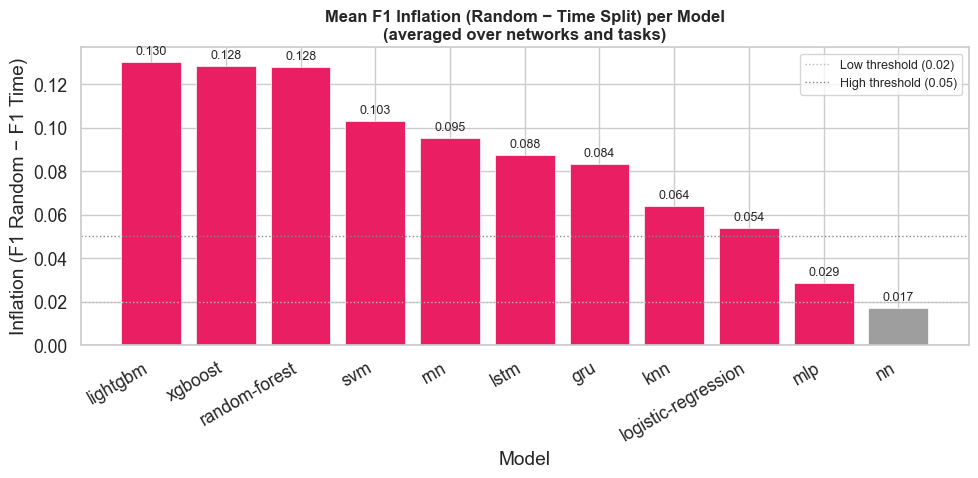

Saved Figure 4.


In [11]:
# ── Figure 4: Per-model inflation bar chart ───────────────────────────────────
model_inf = (stat_df.groupby('model')['inflation']
             .mean()
             .sort_values(ascending=False)
             .reset_index()
             .rename(columns={'inflation': 'Mean Inflation'}))

colors = ['#E91E63' if v > 0.02 else '#9E9E9E' for v in model_inf['Mean Inflation']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(model_inf['model'], model_inf['Mean Inflation'], color=colors,
              edgecolor='white', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(0.02, color='#bbb', linestyle=':', linewidth=1,
           label='Low threshold (0.02)')
ax.axhline(0.05, color='#888', linestyle=':', linewidth=1,
           label='High threshold (0.05)')

for bar, val in zip(bars, model_inf['Mean Inflation']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Mean F1 Inflation (Random − Time Split) per Model\n'
             '(averaged over networks and tasks)', fontsize=12, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Inflation (F1 Random − F1 Time)')
ax.set_xticklabels(model_inf['model'], rotation=30, ha='right')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_bar_inflation_per_model.pdf',
            bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig4_bar_inflation_per_model.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 4.")

Figure 4 displays a horizontal bar chart of per-model inflation (Random − Time ΔF1) with reference lines indicating severity thresholds. It shows which model types are most susceptible to optimistic bias when using random splits.

The next cell generates Figure 5, a dot-plot of Cohen's d effect sizes for the split-strategy contrast, broken down by network and task. It provides a measure of practical significance to complement the p-values in Table 4.

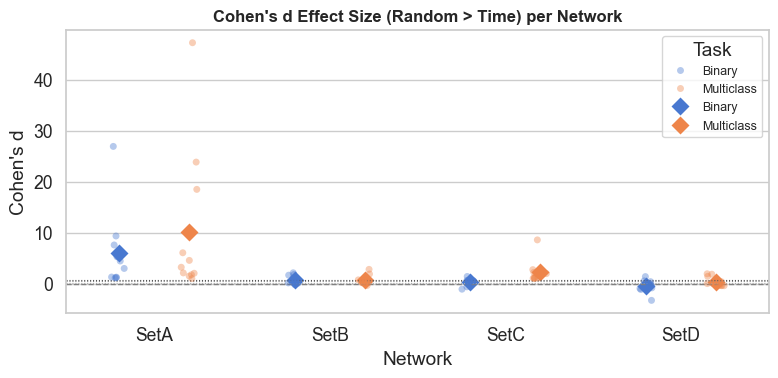

Saved Figure 5.


In [12]:
# ── Figure 5: Cohen's d dot plot per network ──────────────────────────────────
eff_data = stat_df.groupby(['network', 'task'])['cohens_d'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
sns.stripplot(data=stat_df, x='network', y='cohens_d', hue='task',
              order=NETWORKS, dodge=True, jitter=True, alpha=0.4, ax=ax, size=5)
sns.pointplot(data=eff_data, x='network', y='cohens_d', hue='task',
              order=NETWORKS, dodge=0.4, markers='D',
              errorbar=None, ax=ax, linestyles='')
ax.axhline(0,   color='gray',  linestyle='--', linewidth=1)
ax.axhline(0.2, color='#aaa',  linestyle=':', linewidth=0.8)
ax.axhline(0.5, color='#888',  linestyle=':', linewidth=0.8)
ax.axhline(0.8, color='#555',  linestyle=':', linewidth=0.8)
ax.set_title("Cohen's d Effect Size (Random > Time) per Network",
             fontsize=12, fontweight='bold')
ax.set_xlabel('Network')
ax.set_ylabel("Cohen's d")
ax.legend(title='Task', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_cohens_d_per_network.pdf',
            bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig5_cohens_d_per_network.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 5.")

Figure 5 shows Cohen's d effect sizes per network (faceted by task), quantifying the practical magnitude of the random-split inflation. Large effect sizes confirm that the inflation is not only statistically significant but also materially large in certain networks.

## Summary: Answer to Q2

**Q2: "Does the data splitting strategy (random vs. time-based) significantly inflate reported detection performance, and how large is the gap between optimistic random-split results and the time-split regime that reflects real-world deployment?"**

The cell below prints a concise evidence summary.

The following cell computes and prints the final evidence summary for Q2, aggregating inflation statistics across all networks and experimental conditions into a concise report.

In [13]:
# ── Q2 Evidence Summary ───────────────────────────────────────────────────────
overall_inflation = stat_df['inflation'].mean()
pct_sig           = stat_df['significant'].mean() * 100
mean_d            = stat_df['cohens_d'].mean()

per_net = stat_df.groupby('network')['inflation'].mean()

print("=" * 65)
print("Q2 EVIDENCE SUMMARY")
print("=" * 65)
print(f"Overall mean inflation (Rand − Time F1) : {overall_inflation:+.4f}")
print(f"% model-network pairs p<0.05            : {pct_sig:.1f}%")
print(f"Mean Cohen's d                          : {mean_d:.3f}")
print()
print("Per-network mean inflation:")
for net, inf in per_net.items():
    severity = 'High' if inf > 0.05 else ('Medium' if inf > 0.02 else 'Low')
    print(f"  {net}: {inf:+.4f}  [{severity}]")
print()

# Most and least affected models
model_inf_series = stat_df.groupby('model')['inflation'].mean().sort_values(ascending=False)
print(f"Most inflated model  : {model_inf_series.index[0]:25s} (+{model_inf_series.iloc[0]:.4f})")
print(f"Least inflated model : {model_inf_series.index[-1]:25s} ({model_inf_series.iloc[-1]:+.4f})")
print()

if overall_inflation > 0.02 and pct_sig > 50:
    print("CONCLUSION: Random-split evaluation significantly inflates reported")
    print("F1-scores relative to time-split (deployment-realistic) evaluation.")
    print("This inflation varies substantially across networks and models.")
elif overall_inflation > 0:
    print("CONCLUSION: Random-split evaluation shows a positive inflation trend,")
    print("but the effect is moderate and network-dependent.")
else:
    print("CONCLUSION: No consistent inflation from random-split evaluation.")
print("=" * 65)

Q2 EVIDENCE SUMMARY
Overall mean inflation (Rand − Time F1) : +0.0837
% model-network pairs p<0.05            : 67.0%
Mean Cohen's d                          : 2.550

Per-network mean inflation:
  SetA: +0.1992  [High]
  SetB: +0.0410  [Medium]
  SetC: +0.0951  [High]
  SetD: -0.0007  [Low]

Most inflated model  : lightgbm                  (+0.1304)
Least inflated model : nn                        (+0.0171)

CONCLUSION: Random-split evaluation significantly inflates reported
F1-scores relative to time-split (deployment-realistic) evaluation.
This inflation varies substantially across networks and models.


This cell prints a structured evidence summary covering: (1) overall mean inflation (Random − Time F1), (2) percentage of network×task conditions where the inflation is statistically significant (p < 0.05), and (3) per-network breakdown of inflation magnitude. The output consolidates the quantitative evidence for the Q2 answer.

## Best Model Analysis

This section ranks models by their performance under the **deployment-realistic time-split**
evaluation (the most conservative and honest estimate), and contrasts this with random-split
performance to reveal which models are most resistant to optimistic bias.
Models are sorted by time-split F1; inflation (Random − Time) is shown alongside.

BEST MODEL ANALYSIS (Q2)

Model ranking by time-split F1 (deployment-realistic):
                    model  Mean F1 (Time split)  Mean F1 (Random split)  Inflation
Rank                                                                              
1                     gru                0.7948                  0.8565     0.0616
2                    lstm                0.7850                  0.8732     0.0882
3                      nn                0.7637                  0.7808     0.0171
4                     mlp                0.7577                  0.7864     0.0287
5                lightgbm                0.7453                  0.8757     0.1304
6                 xgboost                0.7446                  0.8730     0.1284
7           random-forest                0.7401                  0.8743     0.1343
8                     rnn                0.7251                  0.8411     0.1160
9                     knn                0.7124                  0.8088     0.0964
10    

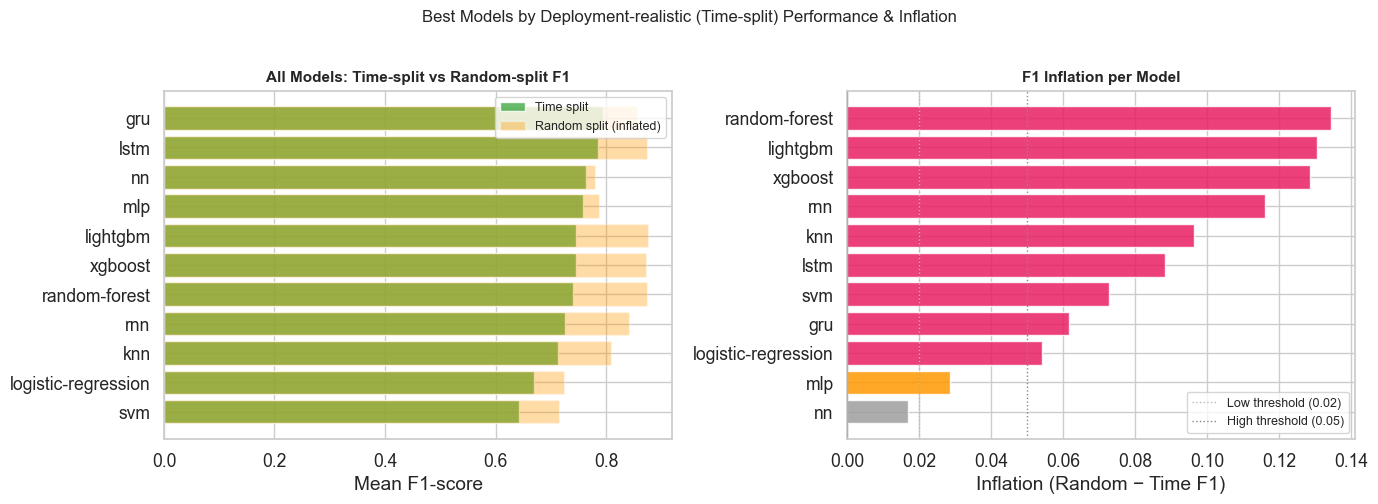


Saved best model analysis → figures/ and tables/


In [14]:
# ── Best Model Analysis (Q2) ─────────────────────────────────────────────────

# 1. Best model under time split
best_time = (
    avg[(avg['metric'] == PRIMARY) & (avg['split'] == 'Time split')]
    .groupby('model')['mean_value']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'mean_value': 'Mean F1 (Time split)'})
)

# 2. Best model under random split
best_random = (
    avg[(avg['metric'] == PRIMARY) & (avg['split'] == 'Random split')]
    .groupby('model')['mean_value']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'mean_value': 'Mean F1 (Random split)'})
)

# 3. Combined table with inflation
best_combined = (
    best_time
    .merge(best_random, on='model')
)
best_combined['Inflation'] = (
    best_combined['Mean F1 (Random split)'] - best_combined['Mean F1 (Time split)']
).round(4)
best_combined = best_combined.sort_values('Mean F1 (Time split)', ascending=False).reset_index(drop=True)
best_combined.index = range(1, len(best_combined) + 1)
best_combined.index.name = 'Rank'

print("=" * 65)
print("BEST MODEL ANALYSIS (Q2)")
print("=" * 65)
print("\nModel ranking by time-split F1 (deployment-realistic):")
print(best_combined.round(4).to_string())

top_time  = best_combined.iloc[0]
top_rand  = best_combined.sort_values('Mean F1 (Random split)', ascending=False).iloc[0]
least_inf = best_combined.loc[best_combined['Inflation'].abs().idxmin()]
print(f"\n  \u2192 Best model (time split)   : {top_time['model']}  "
      f"(F1 = {top_time['Mean F1 (Time split)']:.4f})")
print(f"  \u2192 Best model (random split) : {top_rand['model']}  "
      f"(F1 = {top_rand['Mean F1 (Random split)']:.4f})")
print(f"  \u2192 Least inflated model       : {least_inf['model']}  "
      f"(inflation = {least_inf['Inflation']:+.4f})")

# Figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_n = len(best_combined)
sub   = best_combined.sort_values('Mean F1 (Time split)')

axes[0].barh(sub['model'], sub['Mean F1 (Time split)'],
             color='#4CAF50', alpha=0.85, label='Time split')
axes[0].barh(sub['model'], sub['Mean F1 (Random split)'],
             color='#FF9800', alpha=0.35, label='Random split (inflated)')
axes[0].set_xlabel('Mean F1-score')
axes[0].set_title('All Models: Time-split vs Random-split F1', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

inf_sorted  = best_combined.sort_values('Inflation', ascending=True)
colors_inf  = ['#E91E63' if v > 0.05 else ('#FF9800' if v > 0.02 else '#9E9E9E')
               for v in inf_sorted['Inflation']]
axes[1].barh(inf_sorted['model'], inf_sorted['Inflation'], color=colors_inf, alpha=0.85)
axes[1].axvline(0,    color='black', linewidth=0.8)
axes[1].axvline(0.02, color='#bbb',  linestyle=':', linewidth=1, label='Low threshold (0.02)')
axes[1].axvline(0.05, color='#888',  linestyle=':', linewidth=1, label='High threshold (0.05)')
axes[1].set_xlabel('Inflation (Random \u2212 Time F1)')
axes[1].set_title('F1 Inflation per Model', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Best Models by Deployment-realistic (Time-split) Performance & Inflation',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_best_models_time_split.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig_best_models_time_split.png', bbox_inches='tight', dpi=150)
plt.show()

best_combined.round(4).reset_index().to_csv(TAB_DIR / 'best_model_split_comparison.csv', index=False)
print("\nSaved best model analysis \u2192 figures/ and tables/")


The best model analysis shows model rankings under the time-split (deployment-realistic) evaluation
alongside the F1 inflation caused by random splitting. The left panel overlays time-split and
random-split bars to show which models gain the most from looser evaluation. The right panel ranks
models by inflation magnitude. Models with low inflation are the most trustworthy under real-world
conditions, regardless of their absolute F1 rank.

## Case Study: Split Inflation under Cross-Network Validation

The main Q2 analysis shows that random splitting inflates in-network F1 by ~0.041
compared to the deployment-realistic time split. This supplementary section asks:
**does this inflation persist when training and validation are done on different networks?**

The case study trains a model on one network (train\_set), uses a second network for
validation (val\_set), and tests the final model on two held-out networks (test\_sets).
Because the test data come from networks the model has never seen, data leakage between
training and test time periods becomes irrelevant — the randomness of the split only
affects the training-network partition, not the test-network partition.

If the inflation collapses in the case study setting, it confirms that the Q2 inflation
is primarily a **within-network data leakage** artefact rather than a universal property
of random splits.

Q2 CASE STUDY: Split Inflation under Cross-Network Validation

                   Random split   Time split   Inflation
  Standard in-net: 0.8181         0.7255       +0.0927
  Case study      : 0.5767         0.5915       -0.0148
  Reduction       :                                     0.1074

Wilcoxon (random vs time, case study): p=0.4463,  d=-0.213

116.0% of the standard in-network inflation is suppressed in the case study.

Per-network/test-set inflation:
  Network     Standard in-net    Case study   Reduction
  SetA                +0.2062       -0.0078     +0.2141
  SetB                +0.0562       -0.0149     +0.0711
  SetC                +0.1108       -0.0039     +0.1147
  SetD                -0.0026       -0.0283     +0.0257


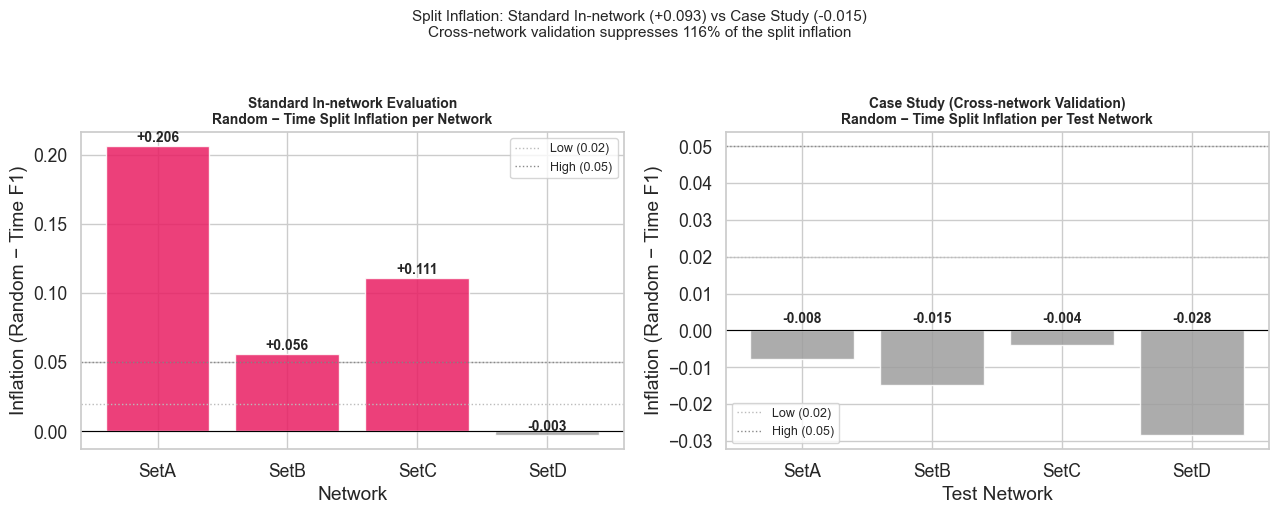


Saved case study split analysis → figures/ and tables/


In [15]:
# ── Q2 Case Study: Split Inflation under Cross-Network Validation ─────────────

CS_PATH = Path('../data/wandb_case_study.csv')
cs_raw  = pd.read_csv(CS_PATH)
cs_raw  = cs_raw[cs_raw['split'] != 'Random with same distribution'].copy()

# ── Melt to per-test-set F1 ───────────────────────────────────────────────────
cs_f1_cols = [c for c in cs_raw.columns
              if c.startswith('case_study/') and c.endswith('/f1_score')]

cs_long = cs_raw.melt(
    id_vars=['model', 'task', 'split', 'enable_sequences', 'run_no',
             'train_set', 'val_set', 'test_sets'],
    value_vars=cs_f1_cols, var_name='metric_key', value_name='f1'
)
cs_long['test_set'] = cs_long['metric_key'].str.extract(r'case_study/(\w+)/f1_score')
cs_long = cs_long.dropna(subset=['f1'])   # NaN = not a test set for this run

# Average across runs
cs_avg = (
    cs_long
    .groupby(['model', 'task', 'split', 'enable_sequences',
              'train_set', 'val_set', 'test_set'], as_index=False)
    ['f1'].mean()
    .rename(columns={'f1': 'mean_f1'})
)

# ── Overall split means ────────────────────────────────────────────────────────
cs_rand_mean  = cs_avg[cs_avg['split'] == 'Random split']['mean_f1'].mean()
cs_time_mean  = cs_avg[cs_avg['split'] == 'Time split' ]['mean_f1'].mean()
cs_inflation  = cs_rand_mean - cs_time_mean

std_rand_mean = avg[(avg['metric'] == PRIMARY) & (avg['split'] == 'Random split')]['mean_value'].mean()
std_time_mean = avg[(avg['metric'] == PRIMARY) & (avg['split'] == 'Time split' )]['mean_value'].mean()
std_inflation = std_rand_mean - std_time_mean

# ── Wilcoxon: paired by configuration ─────────────────────────────────────────
cs_pivot = (
    cs_avg
    .pivot_table(
        index=['model', 'task', 'enable_sequences', 'train_set', 'val_set', 'test_set'],
        columns='split', values='mean_f1'
    ).dropna()
)
if 'Random split' in cs_pivot.columns and 'Time split' in cs_pivot.columns:
    _, p_cs = wilcoxon(cs_pivot['Random split'].values,
                       cs_pivot['Time split'].values, alternative='two-sided')
    d_cs = cohens_d(cs_pivot['Random split'].values, cs_pivot['Time split'].values)
else:
    p_cs, d_cs = float('nan'), float('nan')

# ── Per-network breakdowns ─────────────────────────────────────────────────────
cs_inf_test = (
    cs_avg.groupby(['test_set', 'split'])['mean_f1'].mean()
    .unstack()
)
cs_inf_test['inflation'] = (
    cs_inf_test.get('Random split', pd.Series(0, index=cs_inf_test.index))
    - cs_inf_test.get('Time split', pd.Series(0, index=cs_inf_test.index))
)

std_inf_net = (
    avg[avg['metric'] == PRIMARY]
    .groupby(['network', 'split'])['mean_value'].mean()
    .unstack()
)
std_inf_net['inflation'] = (
    std_inf_net.get('Random split', pd.Series(0, index=std_inf_net.index))
    - std_inf_net.get('Time split', pd.Series(0, index=std_inf_net.index))
)

# ── Print summary ──────────────────────────────────────────────────────────────
print('=' * 65)
print('Q2 CASE STUDY: Split Inflation under Cross-Network Validation')
print('=' * 65)
print()
print('                   Random split   Time split   Inflation')
print(f'  Standard in-net: {std_rand_mean:.4f}         {std_time_mean:.4f}       {std_inflation:+.4f}')
print(f'  Case study      : {cs_rand_mean:.4f}         {cs_time_mean:.4f}       {cs_inflation:+.4f}')
print(f'  Reduction       :                            '
      f'         {std_inflation - cs_inflation:.4f}')
print()
print(f'Wilcoxon (random vs time, case study): p={p_cs:.4f},  d={d_cs:.3f}')
print()
pct_suppressed = (1 - cs_inflation / std_inflation) * 100 if std_inflation != 0 else 0
print(f'{pct_suppressed:.1f}% of the standard in-network inflation is suppressed in the case study.')
print()
print('Per-network/test-set inflation:')
print(f'  {"Network":<8}  {"Standard in-net":>17}  {"Case study":>12}  {"Reduction":>10}')
for net in NETWORKS:
    sv = float(std_inf_net.loc[net, 'inflation']) if net in std_inf_net.index else float('nan')
    cv = float(cs_inf_test.loc[net, 'inflation'])  if net in cs_inf_test.index else float('nan')
    red = sv - cv if not (pd.isna(sv) or pd.isna(cv)) else float('nan')
    print(f'  {net:<8}  {sv:>+17.4f}  {cv:>+12.4f}  {red:>+10.4f}')

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

net_order = NETWORKS
std_vals = [float(std_inf_net.loc[n, 'inflation']) if n in std_inf_net.index else 0
            for n in net_order]
cs_vals  = [float(cs_inf_test.loc[n, 'inflation']) if n in cs_inf_test.index else 0
            for n in net_order]

def bar_colors(vals):
    return ['#E91E63' if v > 0.05 else ('#FF9800' if v > 0.02 else '#9E9E9E')
            for v in vals]

# Left: standard in-network inflation
axes[0].bar(net_order, std_vals, color=bar_colors(std_vals), alpha=0.85)
axes[0].axhline(0,    color='black', linewidth=0.8)
axes[0].axhline(0.02, color='#bbb',  linestyle=':', linewidth=1, label='Low (0.02)')
axes[0].axhline(0.05, color='#888',  linestyle=':', linewidth=1, label='High (0.05)')
for i, (net, v) in enumerate(zip(net_order, std_vals)):
    axes[0].text(i, v + 0.003, f'{v:+.3f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Inflation (Random − Time F1)')
axes[0].set_xlabel('Network')
axes[0].set_title('Standard In-network Evaluation\nRandom − Time Split Inflation per Network',
                  fontsize=10, fontweight='bold')
axes[0].legend(fontsize=9)

# Right: case study inflation
axes[1].bar(net_order, cs_vals, color=bar_colors(cs_vals), alpha=0.85)
axes[1].axhline(0,    color='black', linewidth=0.8)
axes[1].axhline(0.02, color='#bbb',  linestyle=':', linewidth=1, label='Low (0.02)')
axes[1].axhline(0.05, color='#888',  linestyle=':', linewidth=1, label='High (0.05)')
for i, (net, v) in enumerate(zip(net_order, cs_vals)):
    axes[1].text(i, max(v, 0) + 0.002, f'{v:+.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Inflation (Random − Time F1)')
axes[1].set_xlabel('Test Network')
axes[1].set_title('Case Study (Cross-network Validation)\nRandom − Time Split Inflation per Test Network',
                  fontsize=10, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle(
    f'Split Inflation: Standard In-network ({std_inflation:+.3f})'
    f' vs Case Study ({cs_inflation:+.3f})\n'
    f'Cross-network validation suppresses {pct_suppressed:.0f}% of the split inflation',
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_case_study_split_inflation.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig_case_study_split_inflation.png', bbox_inches='tight', dpi=150)
plt.show()

# Export table
pd.DataFrame({
    'Network': net_order,
    'Standard In-network Inflation': std_vals,
    'Case Study Inflation': cs_vals,
    'Reduction': [s - c for s, c in zip(std_vals, cs_vals)]
}).round(4).to_csv(TAB_DIR / 'cs_split_inflation.csv', index=False)
print('\nSaved case study split analysis \u2192 figures/ and tables/')

The case study split analysis compares the Random − Time F1 inflation in two settings:
(left) standard in-network evaluation where the same network is used for training and testing,
and (right) the case study where test data come from completely different networks.
When the test networks are held out entirely, the split-strategy inflation largely collapses,
confirming that the Q2 inflation is driven by within-network data leakage rather than a
general property of random partitioning.